In [2]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os
load_dotenv()

if os.environ['OPENAI_API_KEY']:
    print('i am there')
else:
    print('API key not found')

i am there


In [4]:
llm= ChatOpenAI(model="gpt-5-nano")

In [21]:


from pydantic import BaseModel, Field

class GraphSchema(BaseModel):   # Class name should be PascalCase
    topic: str = Field(description="ncsjn")
    post: str = Field(description="the linkedin post content")
    curated_post: str = Field(description="the linkedin curated post content")  # snake_case preferred

demo_object = GraphSchema(topic="AI", post="LA", curated_post="MA")
print(demo_object)


topic='AI' post='LA' curated_post='MA'


In [38]:
def create_post(state:  GraphSchema)-> GraphSchema:
    
    post= state.post
    post_response = llm.invoke(f"create a linkedin post on the  with the content {post}").content
    state.post = post_response
    return state

def create_curated_post(state:  GraphSchema)-> GraphSchema:
    
    curated_posts= state.curated_post
    curated_response = llm.invoke(f"create a linkedin post on the  with the content {curated_posts}").content
    state.curated_post = curated_response
    return state


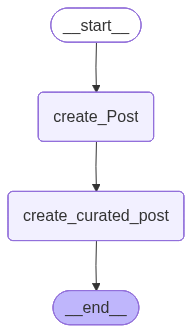

In [39]:
from langgraph.graph  import StateGraph, START, END
link_graphobject= StateGraph(GraphSchema)

link_graphobject.add_node("create_Post",create_post)
link_graphobject.add_node("create_curated_post",create_curated_post)

link_graphobject.add_edge(START,"create_Post")
link_graphobject.add_edge("create_Post","create_curated_post")

link_graphobject.add_edge("create_curated_post",END)
pydantic_graph =link_graphobject.compile()

from IPython.display import Image, display
Image (pydantic_graph.get_graph().draw_mermaid_png())



In [41]:
pydantic_graph.invoke(
    { "topic": "AI",
      "post": "", 
      "curated_post": ""
    }
)

{'topic': 'AI',
 'post': 'I’m missing the topic and tone. Could you share:\n- Topic or content you want the post to cover\n- Audience (industry, role)\n- Tone (professional, inspirational, friendly, thought leadership)\n- Desired length\n- Any key points or a call to action\n- Hashtags you’d like to include\n\nIn the meantime, here are a few ready-to-use templates you can customize:\n\nTemplate A — Concise and professional (about 90–120 words)\n- Post: “Proud to share a quick update on [topic]. Over the past [timeframe], we’ve seen [key insight or result], which reinforces [lesson]. For anyone working in [relevant area], consider [actionable tip]. Grateful for the team and partners who made this possible. What’s one change you’re making in your [area]? [CTA]”\n- Hashtags (example): #leadership #innovation #industry\n\nTemplate B — Thought leadership / storytelling (150–250 words)\n- Post: “Last quarter, our team faced [challenge]. Instead of [default approach], we chose [approach], and